<img src="images/logo.png" width=180, align="center"/>

Master's degree in Intelligent Systems

Subject: 11754 - Deep Learning

Year: 2025-2026

Professor: Miguel Ángel Calafat Torrens

# LAB 4 — Diffusion Models

**In this lab you have to deliver only this file, perfectly completed, executed and showing the outputs of the cells.**

This lab builds on the concepts from LESSON 4A (theory, forward process, UNet architecture) and LESSON 4B (training, noise schedules, inference). You will complete 5 exercises that require both implementation and written analysis.

## Exercises Overview
- **Exercise A** — Architecture Analysis (no GPU, written)
- **Exercise B** — Training Analysis Experiment (moderate GPU)
- **Exercise C** — Noise Schedule Analysis (low GPU)
- **Exercise D** — Reverse Process & Partial Denoising (low GPU)
- **Exercise E** — Critical Thinking (no GPU, written)

**You can modify, add or remove any cell that you want to fulfill the requirements.**

**Written analysis guidelines:** All exercises with written components should demonstrate understanding of the underlying concepts. Minimum word counts are indicated per exercise.

In [1]:
# Connect to your drive (Colab only)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/gdrive')
    %cd '/content/gdrive/MyDrive/LABS2026/LAB04'
    %ls -l

In [2]:
import logging
import os
import pathlib
import sys

import torch
from torch import nn, optim
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm

import time

PROJECT_DIR = str(pathlib.Path().resolve())
sys.path.append(PROJECT_DIR)

import helper_L4 as hp

logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s",
                    level=logging.INFO, datefmt="%I:%M:%S")

DEVICE = torch.device("mps")
hp.DEVICE = DEVICE

print(f"Using device: {DEVICE}")

Using device: mps


In [3]:
# Dataset setup: extract from zip if needed
if IN_COLAB:
    dataset_zip = '/content/gdrive/MyDrive/datasets/landscape_pictures_1000.zip'
else:
    dataset_zip = os.path.join(PROJECT_DIR, 'landscape_pictures_1000.zip')

print(dataset_zip)

DATASET_PATH = hp.extract_dataset(dataset_zip, remove_zip=IN_COLAB)
dataloader = hp.get_data_flat(DATASET_PATH, image_size=64, batch_size=4)

/Users/einar/Documents/EDISS/UIB/DL/LAB04/landscape_pictures_1000.zip
Dataset folder already exists: /Users/einar/Documents/EDISS/UIB/DL/LAB04/landscape_pictures_1000


---
# Exercise A — Architecture Analysis (no GPU, written)

**Requirements:**

1. Read the `UNet` class in `helper_L4.py`. For an input of shape `(1, 3, 64, 64)` and timestep `t=500`, manually trace the tensor shape at each stage of the forward pass. Create a table: layer → input shape → output shape for: `inc`, `down1`, `sa1`, `down2`, `sa2`, `down3`, `sa3`, `bot1-3`, `up1`, `sa4`, `up2`, `sa5`, `up3`, `sa6`, `outc`.

2. Calculate total trainable parameters and break down by encoder, bottleneck, decoder.

3. Explain why **skip connections** are critical for denoising — what information flows through them that the bottleneck alone cannot preserve?

4. The SelfAttention blocks are placed at specific resolutions: in the encoder at 32×32, 16×16, 8×8; in the decoder at 16×16, 32×32, 64×64. Explain why self-attention is **NOT** placed at the 64×64 input resolution in the encoder path. What would be the computational cost?

In [33]:
# Exercise A — Shape tracing and parameter counting
model = hp.UNet(device='cpu')

# Your code here: trace shapes and count parameters

**Exercise A — Written Analysis (minimum 200 words):**

*Write your shape table and analysis here.*

---
# Exercise B — Training Analysis Experiment (moderate GPU)

**Requirements:**

Use the `train()` function demonstrated in LESSON 4B (or your own adaptation). Run **3 training experiments**, each for **30 epochs**:

1. **Baseline**: no learning rate scheduler.
2. **CosineAnnealingLR**: use `torch.optim.lr_scheduler.CosineAnnealingLR`. Choose appropriate `T_max` and `eta_min` values.
3. **A scheduler of YOUR choice** (e.g., StepLR, ExponentialLR, OneCycleLR, ReduceLROnPlateau — you choose and justify).

For each run, **re-initialize the model from scratch**.

After all 3 runs:
- (a) Plot all 3 loss curves on the **same figure** with a legend.
- (b) Generate 4 sample images from each of the 3 trained models and display them side by side (3 columns × 4 rows).
- (c) **Written analysis (min 200 words):** compare convergence speed, final loss, and visual quality. Explain why you chose your third scheduler and how it performed.

In [4]:
# Exercise B — Train Function

def train(model, dataloader, diffusion, epochs=5, lr=3e-4, device=DEVICE,
          scheduler=None, plot_loss=True, verbose=True):
    """Train a diffusion model.

    Args:
        model: UNet model.
        dataloader: Training data.
        diffusion: Diffusion instance.
        epochs: Number of epochs.
        lr: Learning rate.
        device: Torch device.
        scheduler: Optional LR scheduler (created externally).
        plot_loss: If True, plot the loss curve at the end.
        verbose: If True, show tqdm progress bar and per-epoch log messages.

    Returns:
        tuple: (epoch_losses, training_time_seconds)
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    epoch_losses = []

    # If scheduler is provided as a class/constructor, instantiate it
    if scheduler is not None and callable(scheduler):
        scheduler = scheduler(optimizer)
    
    start_time = time.perf_counter()

    for epoch in range(epochs):
        pbar = tqdm(dataloader, desc=f"Epoch {epoch}", disable=not verbose)
        epoch_loss = 0.0
        n_batches = 0

        for images, _ in pbar:
            images = images.to(device)
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.noise_images(images, t)
            predicted_noise = model(x_t, t)
            loss = mse(noise, predicted_noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pbar.set_postfix(MSE=loss.item())
            epoch_loss += loss.item()
            n_batches += 1

        if scheduler is not None:
            scheduler.step()

        avg_loss = epoch_loss / n_batches
        epoch_losses.append(avg_loss)
        if verbose:
            logging.info(f"Epoch {epoch} avg loss: {avg_loss:.6f}")

    training_time = time.perf_counter() - start_time
    print(f"Training finished in {training_time:.1f}s ({training_time/60:.2f} min)")

    if plot_loss:
        # Plot loss curve
        plt.figure(figsize=(8, 4))
        plt.plot(epoch_losses, marker='o')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Average MSE Loss')
        plt.grid(True)
        plt.show()

    return epoch_losses, training_time

In [5]:
# Exercise B — Diffusion Object
diffusion_b = hp.Diffusion(img_size=64, device=DEVICE)

In [6]:
# Exercise B — Run 1: Baseline (30 epochs, no scheduler)
model_b1 = hp.UNet(device=DEVICE).to(DEVICE)
losses_b1, training_time_b1 = train(model_b1, dataloader, diffusion_b, epochs=30, plot_loss=False, verbose=False)

Training finished in 6812.1s (113.54 min)


In [7]:
# Exercise B — Run 2: CosineAnnealingLR (30 epochs)
model_b2 = hp.UNet(device=DEVICE).to(DEVICE)
cosine_scheduler = lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30, eta_min=3e-6)
losses_b2, training_time_b2 = train(model_b2, dataloader, diffusion_b, epochs=30,
                  scheduler=cosine_scheduler, plot_loss=False, verbose=False)

Training finished in 24442.6s (407.38 min)


In [8]:
# Exercise B — Run 3: Your chosen scheduler (30 epochs)
model_b3 = hp.UNet(device=DEVICE).to(DEVICE)
onecycle_scheduler = lambda opt: optim.lr_scheduler.OneCycleLR(
    opt, max_lr=3e-4, total_steps=30, pct_start=0.3)
losses_b3, training_time_b3 = train(model_b3, dataloader, diffusion_b, epochs=30,
                  scheduler=onecycle_scheduler, plot_loss=False, verbose=False)

Training finished in 97923.8s (1632.06 min)


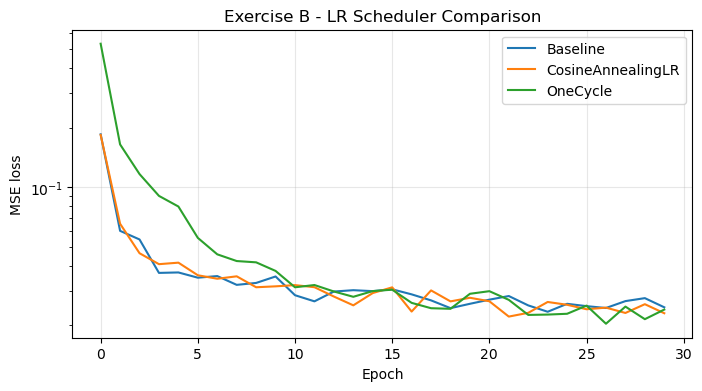

In [9]:
# Exercise B — Plot all 3 loss curves overlaid
plt.figure(figsize=(8, 4))
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.title('Exercise B - LR Scheduler Comparison')
plt.plot(losses_b1, label='Baseline')
plt.plot(losses_b2, label='CosineAnnealingLR')
plt.plot(losses_b3, label='OneCycle')
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.legend()
plt.show()

In [10]:
# Exercise B — Final Loss and Training Time
print(f"Baseline:   {training_time_b1:.1f}s, final loss {losses_b1[-1]:.4f}")
print(f"Cosine:     {training_time_b2:.1f}s, final loss {losses_b2[-1]:.4f}")
print(f"OneCycle:   {training_time_b3:.1f}s, final loss {losses_b3[-1]:.4f}")

Baseline:   6812.1s, final loss 0.0247
Cosine:     24442.6s, final loss 0.0230
OneCycle:   97923.8s, final loss 0.0241


05:51:49 - INFO: Sampling 4 new images....
999it [05:20,  3.12it/s]
05:57:11 - INFO: Sampling 4 new images....
999it [04:57,  3.35it/s]
06:02:09 - INFO: Sampling 4 new images....
999it [04:35,  3.63it/s]


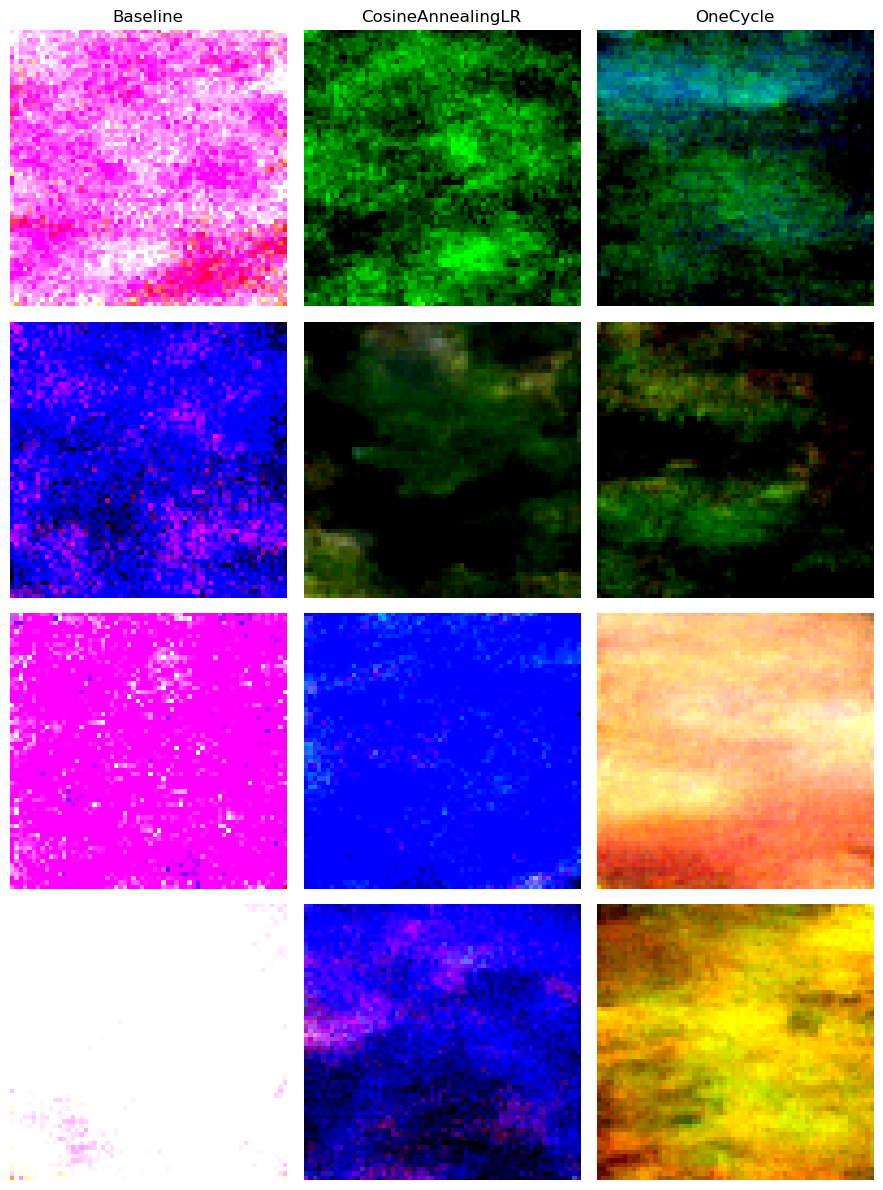

In [11]:
# Exercise B — Generate and compare samples from all 3 models
samples_b1 = diffusion_b.sample(model_b1, 4)
samples_b2 = diffusion_b.sample(model_b2, 4)
samples_b3 = diffusion_b.sample(model_b3, 4)

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
all_samples = [samples_b1, samples_b2, samples_b3]
titles = ['Baseline', 'CosineAnnealingLR', 'OneCycle']

for col, (samples, title) in enumerate(zip(all_samples, titles)):
    for row in range(4):
        img = samples[row].permute(1, 2, 0).cpu().numpy()  # (H, W, 3), uint8
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(title)

plt.tight_layout()
plt.show()

**Exercise B — Written Analysis (minimum 200 words):**

*Write your analysis here comparing the 3 training experiments.*

---
# Exercise C — Noise Schedule Analysis (low GPU)

**Requirements:**

1. Implement a `SigmoidDiffusion` class that subclasses `hp.Diffusion`. Override `prepare_noise_schedule` with a sigmoid function: $\beta(t) = \beta_{\text{start}} + (\beta_{\text{end}} - \beta_{\text{start}}) \cdot \sigma(s \cdot (t - 0.5))$, normalized to ensure $\beta$ spans exactly $[\beta_{\text{start}}, \beta_{\text{end}}]$. Use `sigmoid_scale=8.0`.

2. Test your implementation with `hp.test_sigmoid_diffusion()`.

3. Create a figure with **3 subplots** showing $\beta_t$, $\bar{\alpha}_t$, and $\log(\text{SNR})$ for all 3 schedules (linear via `hp.Diffusion`, cosine via `hp.CosineDiffusion`, sigmoid via your class) overlaid.

4. Using a sample image from the dataset, visualize forward diffusion at $t = [0, 200, 400, 600, 800, 999]$ for ALL 3 schedules: 3 rows × 6 columns.

5. **Written analysis (min 200 words):** which schedule preserves more information at intermediate steps? Why? What does the log(SNR) plot reveal about information decay rates?

In [ ]:
# Exercise C — SigmoidDiffusion
class SigmoidDiffusion(hp.Diffusion):
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02,
             sigmoid_scale=8.0, img_size=256, device="cuda"):
        self.sigmoid_scale = sigmoid_scale
        super().__init__(noise_steps, beta_start, beta_end, img_size, device)

    def prepare_noise_schedule(self):
        t = torch.linspace(0, 1, self.noise_steps)                   
        sig = torch.sigmoid(self.sigmoid_scale * (t - 0.5))           
        sig_norm = (sig - sig.min()) / (sig.max() - sig.min())        
        beta = self.beta_start + (self.beta_end - self.beta_start) * sig_norm
        return beta

In [5]:
# Exercise C — Test implementation
hp.test_sigmoid_diffusion(SigmoidDiffusion, plot=False)

✅ All tests passed! The SigmoidDiffusion implementation is correct.


{'passed': True, 'errors': []}

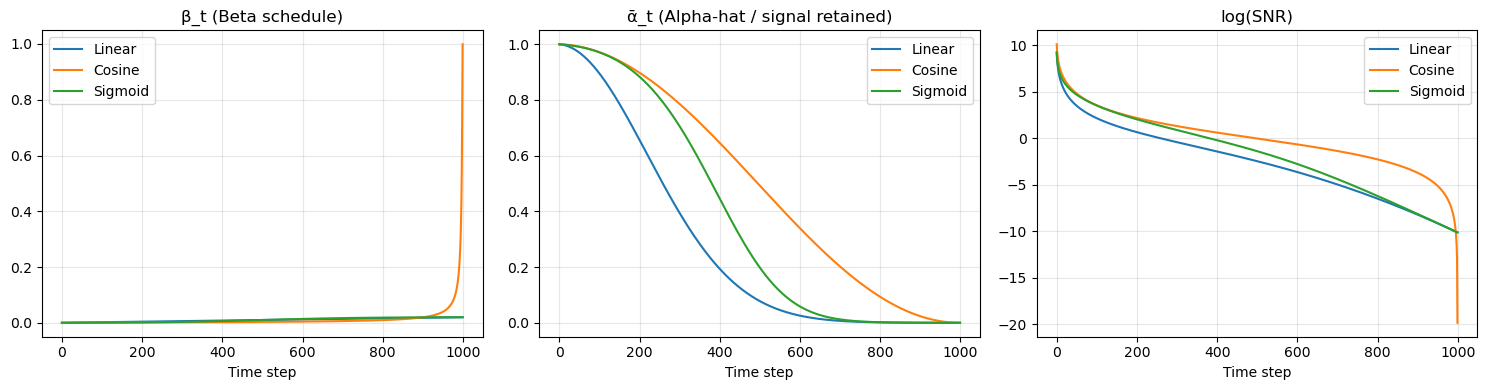

In [22]:
# Exercise C — Schedule comparison plots (3 subplots: beta_t, alpha_bar_t, log(SNR))
linear  = hp.Diffusion(noise_steps=1000, img_size=64, device='cpu')
cosine  = hp.CosineDiffusion(noise_steps=1000, img_size=64, device='cpu')
sigmoid = SigmoidDiffusion(noise_steps=1000, img_size=64, device='cpu')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, d in [("Linear", linear), ("Cosine", cosine), ("Sigmoid", sigmoid)]:
    axes[0].plot(d.beta.cpu().numpy(), label=label)
    axes[1].plot(d.alpha_hat.cpu().numpy(), label=label)
    snr = d.alpha_hat / (1 - d.alpha_hat + 1e-8)
    axes[2].plot(torch.log(snr).cpu().numpy(), label=label)

axes[0].set_title("β_t (Beta schedule)")
axes[1].set_title("ᾱ_t (Alpha-hat / signal retained)")
axes[2].set_title("log(SNR)")
for ax in axes:
    ax.set_xlabel("Time step")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

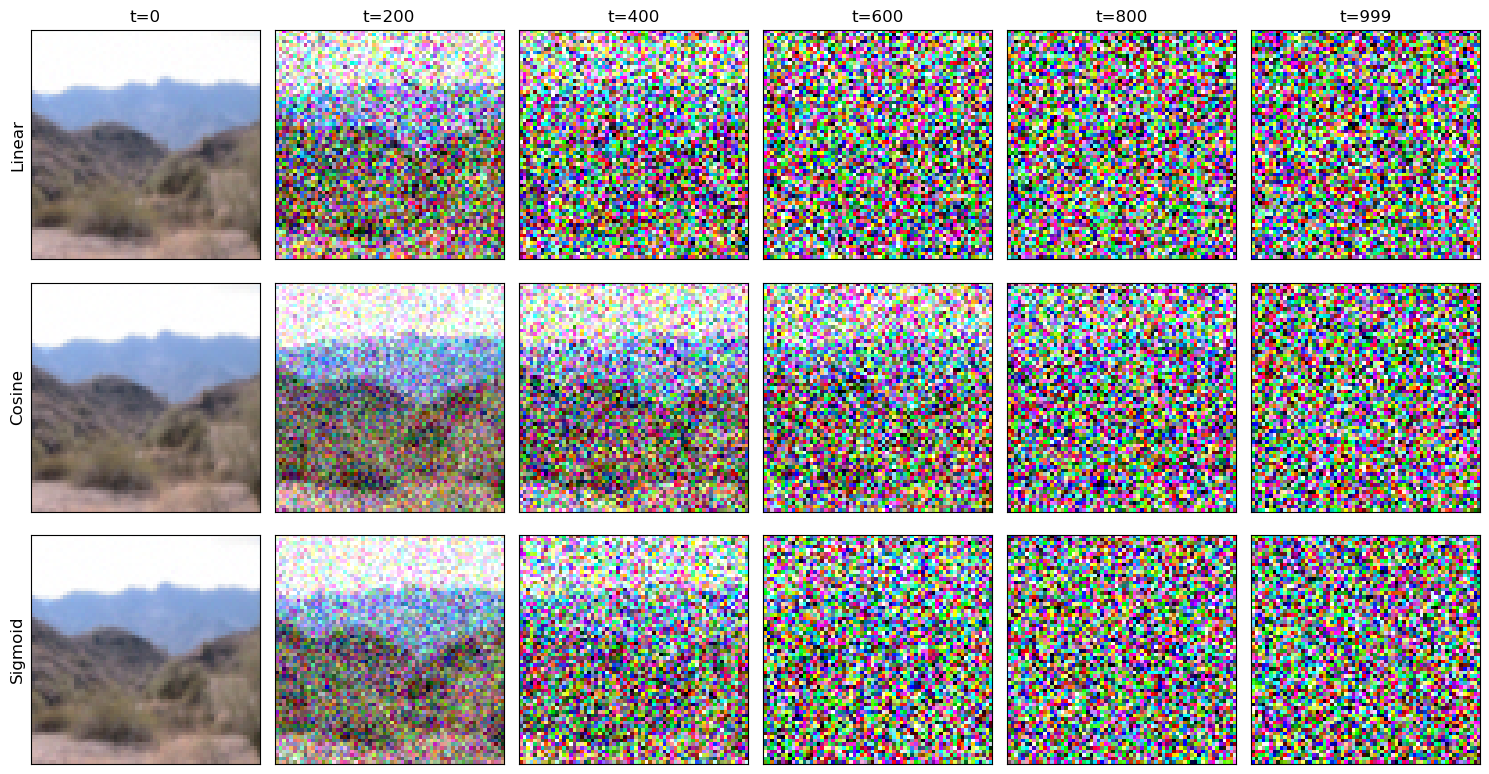

In [29]:
# Exercise C — Forward diffusion visualization (3 rows × 6 cols)
loader = hp.get_data_flat(DATASET_PATH, image_size=64, batch_size=1, limit=1)
images, _ = next(iter(loader))
x0 = images[0].unsqueeze(0)   # shape (1, 3, 64, 64)

timesteps = [0, 200, 400, 600, 800, 999]
schedules = [("Linear", linear), ("Cosine", cosine), ("Sigmoid", sigmoid)]

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row, (name, d) in enumerate(schedules):
    for col, t in enumerate(timesteps):
        x_t, _ = d.noise_images(x0, torch.tensor([t], device="cpu"))
        img = (x_t[0].permute(1, 2, 0) * 0.5 + 0.5).clip(0, 1).numpy()
        axes[row, col].imshow(img)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(f"t={t}")
    axes[row, 0].set_ylabel(name, fontsize=12)
plt.tight_layout()
plt.show()

**Exercise C — Written Analysis (minimum 200 words):**

*Write your analysis here about noise schedules.*

---
# Exercise D — Partial Denoising & Image Generation (low GPU)

**Requirements:**

1. Load the pretrained model (`models/unconditional_ckpt.pt`).

2. Generate 16 images and display in a 4×4 grid.

3. **Partial denoising experiment:** Take a real image from the dataset. Add noise to $t=300$, $t=500$, and $t=700$ using `diffusion.noise_images()`. Then denoise each back to $t=0$ using `diffusion.denoise_step()` in a loop. Display in a single figure: original, partially denoised from $t=300$, from $t=500$, from $t=700$, and a fully generated image (from $t = \text{noise\_steps} - 1$).

4. **Written analysis (min 200 words):** why does more noise → more "creative" output? Relate to $\bar{\alpha}_t$ values. What is the practical application of partial denoising (img2img)?

In [ ]:
# Exercise D — Load pretrained model

In [ ]:
# Exercise D — Generate 16 images (4×4 grid)

In [ ]:
# Exercise D — Partial denoising experiment

**Exercise D — Written Analysis (minimum 200 words):**

*Write your analysis here about partial denoising and its relationship to $\bar{\alpha}_t$.*

---
# Exercise E — Critical Thinking (no GPU, written)

Answer the following questions. Each answer: 100–200 words.

1. **Sampling speed**: DDPM needs $T=1000$ forward passes for ONE image. A GAN generates in a single pass. Calculate the time to generate 16 images assuming 50ms per UNet pass and 20ms per GAN pass. Research DDIM (Song et al., 2020) and explain how it reduces sampling steps. What is the key mathematical insight?

2. **ε-prediction vs x₀-prediction**: Using $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon$, show algebraically that knowing $\epsilon$ is equivalent to knowing $x_0$ (given $x_t$ and $t$). Then explain intuitively why predicting $\epsilon$ leads to more stable training.

**Exercise E — Answers:**

**1.** *Your answer here.*

**2.** *Your answer here.*